In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
df = pd.read_csv("androfuzz-mlc/balanced_dataset_risky.csv")  # Replace with your actual CSV filename
print(f"Dataset shape: {df.shape}")

Dataset shape: (700, 15)


In [8]:
# Convert label column to numeric values using label_map
label_map = {
    0 : 'benign',1 : 'malware',2 : 'risky'
}



print("Label conversion complete")
print(df['label'].value_counts().sort_index())

Label conversion complete
label
0    300
1    300
2    100
Name: count, dtype: int64


In [10]:
X = df.drop('label', axis=1).select_dtypes(include=[np.number])  # also drop hash column (1)
y = df['label']

# Compute correlation of each feature with label
correlations = X.corrwith(y)

# Sort by absolute correlation
corr_sorted = correlations.abs().sort_values(ascending=False)

print(corr_sorted.head(10))

num_providers      0.569116
num_receivers      0.461972
num_services       0.396143
total_methods      0.343429
num_files          0.312719
num_permissions    0.302639
file_size_kb       0.182389
has_native_code    0.150287
version_code       0.106591
package_name       0.068368
dtype: float64


/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [16]:
TOP_N = 10

top_features = corr_sorted.head(TOP_N).index.tolist()

print("Selected feature indices:", top_features)

Selected feature indices: ['num_providers', 'num_receivers', 'num_services', 'total_methods', 'num_files', 'num_permissions', 'file_size_kb', 'has_native_code', 'version_code', 'package_name']


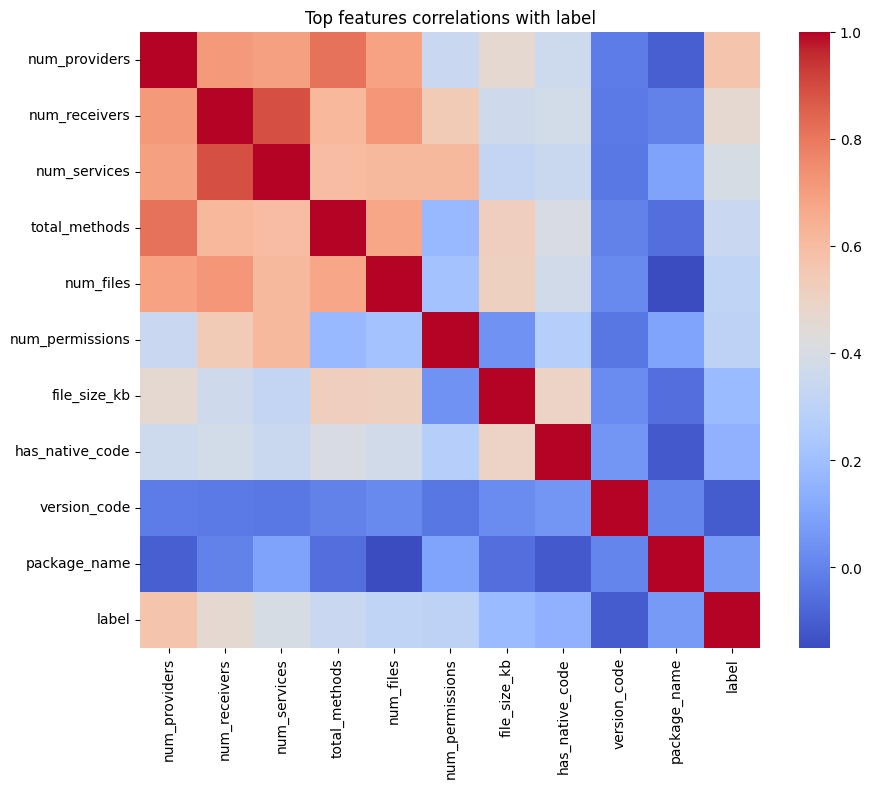

In [17]:
corr_matrix = df[top_features + ['label']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Top features correlations with label")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Remove rows with NaN labels
valid_indices = y.notna()
X_reduced = X[top_features][valid_indices]
y_clean = y[valid_indices]

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y_clean,
    test_size=0.2,
    stratify=y_clean,
    random_state=42
)

#model - RandomForestClassifier with hyperparameters tuned for multiclass classification
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
target_names = [label_map[i] for i in sorted(label_map.keys())]

print("Multiclass Accuracy:", model.score(X_test, y_test))
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=sorted(label_map.keys()),
        target_names=target_names
    )
)

Multiclass Accuracy: 0.9642857142857143

Classification Report:
              precision    recall  f1-score   support

      benign       0.97      0.95      0.96        60
     malware       0.97      0.97      0.97        60
       risky       0.95      1.00      0.98        20

    accuracy                           0.96       140
   macro avg       0.96      0.97      0.97       140
weighted avg       0.96      0.96      0.96       140



In [20]:
#cross validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_reduced, y_clean, cv=5)
print(scores.mean())

0.917142857142857


In [22]:
import shap
from sklearn.ensemble import RandomForestClassifier

rf_shap = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, # Limited depth for faster SHAP calculation
    random_state=42, 
    n_jobs=-1
)
rf_shap.fit(X_train, y_train)

# 2. Initialize the Explainer
# TreeExplainer is optimized specifically for Random Forests
explainer = shap.TreeExplainer(rf_shap)

# 3. Generate SHAP values for a sample
# We use a sample because calculating SHAP for the whole test set is slow
sample_size = min(500, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=42)
shap_explanations = explainer(X_sample)
shap_values = shap_explanations.values

Generating Detailed Beeswarm for Class 0...


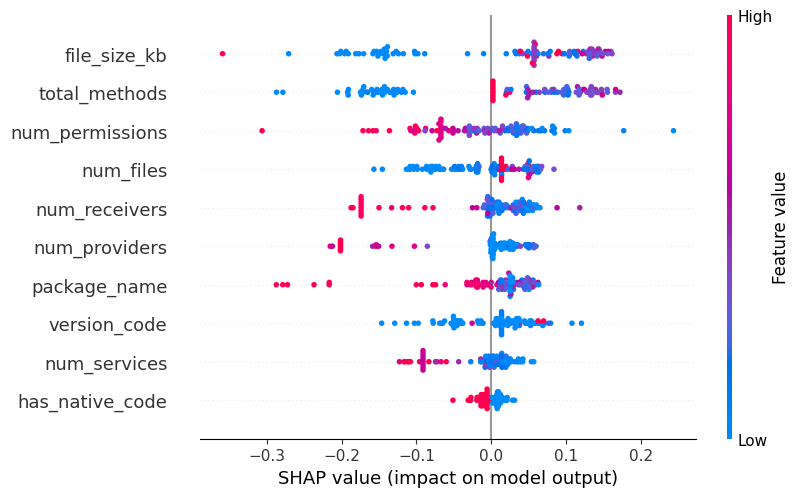

In [23]:
target_class_index = 0
print(f"Generating Detailed Beeswarm for Class {target_class_index}...")
shap.plots.beeswarm(shap_explanations[:, :, target_class_index])

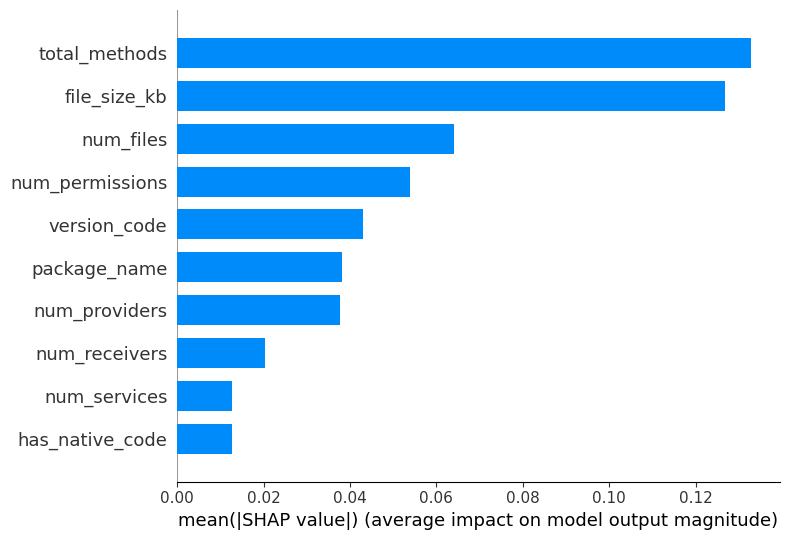

In [24]:
shap.summary_plot(shap_values[:, :, 1], X_sample, plot_type="bar")

Generating explanation for Class: benign (Index 0)


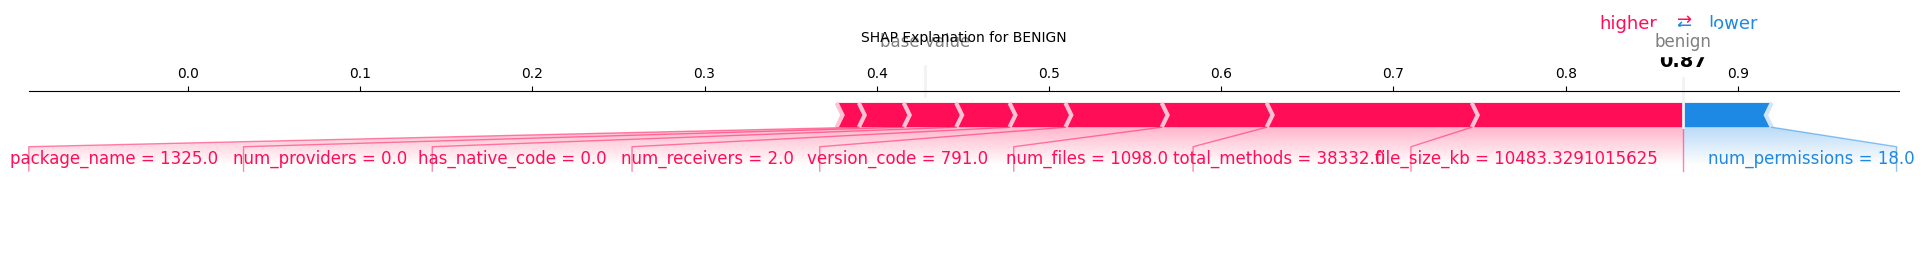

Generating explanation for Class: malware (Index 1)


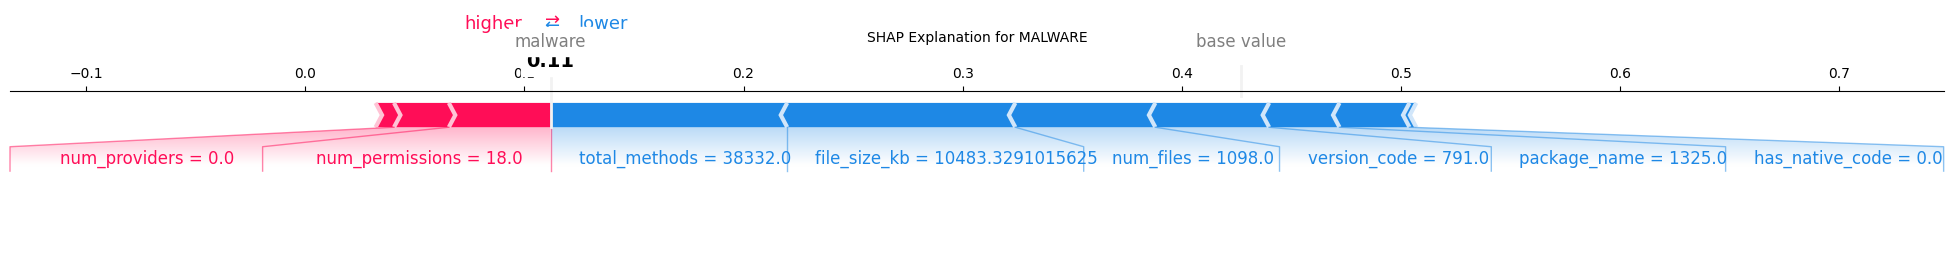

Generating explanation for Class: risky (Index 2)


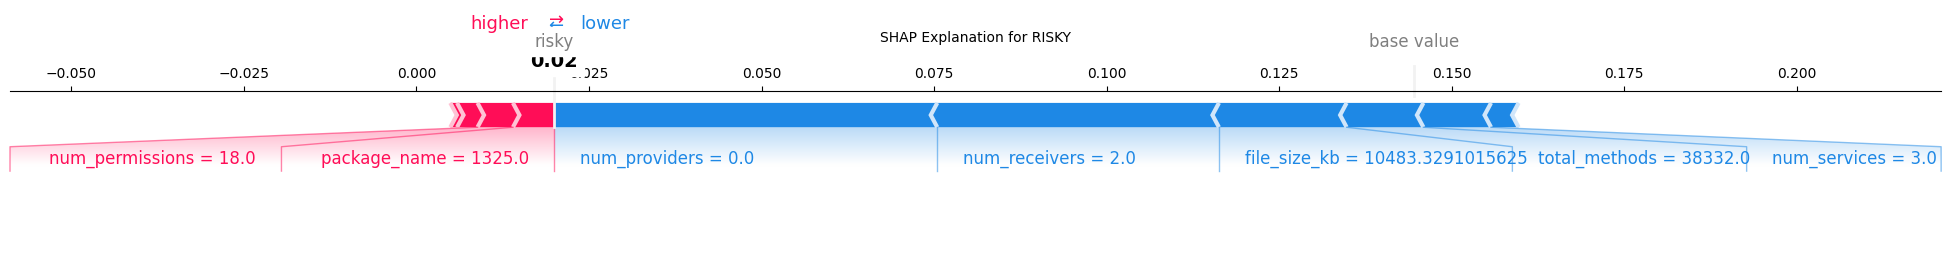

In [26]:
inv_label_map = {k: v for k, v in label_map.items()}

# 2. Select the app and the class you want to explain
i = 0  # Index of the Android app in X_sample

for target_class_index in sorted(inv_label_map.keys()):
    # 3. Prepare data for the plot
    features_row = X_sample.iloc[i, :]
    feature_names = X_sample.columns.tolist()
    features_display = features_row.astype(float).values
    class_name = inv_label_map[target_class_index]

    # 4. Generate the Force Plot
    print(f"Generating explanation for Class: {class_name} (Index {target_class_index})")

    shap.force_plot(
        float(explainer.expected_value[target_class_index]),
        shap_values[i, :, target_class_index],
        features_display,
        feature_names=feature_names,
        out_names=class_name,  # This labels the final value as the specific malware type
        matplotlib=True,
        show=False
    )

    # 5. Clean up the title and layout
    plt.title(f"SHAP Explanation for {class_name.upper()}", fontsize=10, pad=18)
    plt.tight_layout()
    plt.show()


In [28]:
sample = X_test.sample(n=100, random_state=42).reset_index(drop=True)
pred = model.predict(sample)

# 1. Setup the explainer and explanations
explainer_model = shap.TreeExplainer(model)
# Note: For some RF versions, you might need to use shap_values = explainer.shap_values(sample)
# but the standard explainer call is usually preferred:
shap_explanations_model = explainer_model(sample, check_additivity=False)

# Class index -> class name map
inv_label_map = {k: v for k, v in label_map.items()}

# 2. Iterate through the predictions
for i, app_pred_idx in enumerate(pred):
    # Convert to integer for indexing
    app_pred_idx = int(app_pred_idx)
    
    # Get the human-readable name of the predicted class
    predicted_class_name = inv_label_map.get(app_pred_idx, f"class_{app_pred_idx}")
    
    # DYNAMIC INDEXING: 
    # Get the SHAP values for the specific class that was PREDICTED
    # shap_explanations_model.values shape is (samples, features, classes)
    current_shap_values = shap_explanations_model.values[i, :, app_pred_idx]
    feature_names = sample.columns
    
    # Sort features by their impact (top 3)
    top_indices = np.argsort(np.abs(current_shap_values))[-3:][::-1]
    
    reasons = []
    for idx in top_indices:
        val = current_shap_values[idx]
        feature_name = feature_names[idx]
        
        # If SHAP is positive, it increased the probability of this class
        # If SHAP is negative, it decreased the probability
        if val > 0:
            direction = f"increased evidence for {predicted_class_name}"
        else:
            direction = f"decreased evidence for {predicted_class_name}"
            
        reasons.append(f"{feature_name} ({direction} by {abs(val):.4f})")
        
    print(f"App {i}: Predicted as [{predicted_class_name.upper()}]")
    print(f"   Top Reasons: {', '.join(reasons)}\n")

App 0: Predicted as [MALWARE]
   Top Reasons: total_methods (increased evidence for malware by 0.2361), file_size_kb (increased evidence for malware by 0.1671), num_files (increased evidence for malware by 0.1470)

App 1: Predicted as [MALWARE]
   Top Reasons: file_size_kb (increased evidence for malware by 0.2273), total_methods (increased evidence for malware by 0.2125), num_providers (increased evidence for malware by 0.0726)

App 2: Predicted as [MALWARE]
   Top Reasons: total_methods (increased evidence for malware by 0.1821), num_files (increased evidence for malware by 0.1685), file_size_kb (decreased evidence for malware by 0.0824)

App 3: Predicted as [MALWARE]
   Top Reasons: package_name (increased evidence for malware by 0.2483), num_providers (increased evidence for malware by 0.0798), num_permissions (decreased evidence for malware by 0.0592)

App 4: Predicted as [MALWARE]
   Top Reasons: total_methods (increased evidence for malware by 0.1919), file_size_kb (increased ev